# Week 6 Shootout

此作業範例選用2025年7月28日的0728豪雨事件，以及2025年11月11日的鳳凰颱風。在降雨型態的差異上，0728豪雨事件為當時周圍颱風帶來的兩波西南氣流影響，所造成的極端降雨事件。西南氣流夾帶的大量水氣，此次降雨對中南部造成致災性的超大豪雨，但對東部地區影響不大，且降雨範圍較為平均。而鳳凰颱風的時節位於冬天，因此外圍環流與東北季風的共伴效應，則對北部及東部地區帶來致災性的超大豪雨，特別對蘇澳地區造成重大影響。因此，本作業將比較兩種不同降雨型態的降雨分布特徵。

📝 **Captain's Log: Phase 1 - 降雨資料設定與坐標系統校準**

載入0728豪雨事件與鳳凰颱風的24小時累積雨量資料，鎖定目標防區為「花蓮縣」與「宜蘭縣」，並剔除雨量為 `-998`（儀器異常）與 `0` 的測站。坐標系統設定為EPSG:3826，以便 Kriging 計算。

In [17]:
import pandas as pd
import geopandas as gpd

def preprocess_rainfall_data(file_path, target_col='Past24hr'):
    """讀取降雨資料，篩選縣市、取最新時間點，並轉換坐標系為 EPSG:3826。"""
    df = pd.read_csv(file_path)
    df_filtered = df[df['CountyName'].isin(['花蓮縣', '宜蘭縣'])].copy()
    
    # 確保 DateTime 為時間格式，並針對每個測站取得「時間最晚」的那一筆
    df_filtered['DateTime'] = pd.to_datetime(df_filtered['DateTime'])
    idx = df_filtered.groupby('StationId')['DateTime'].idxmax()
    df_filtered = df_filtered.loc[idx].copy()
    
    # 過濾異常值與無雨狀態
    df_filtered = df_filtered[(df_filtered[target_col] != -998) & (df_filtered[target_col] > 0)]
    
    # 建立空間資料並轉換 CRS
    gdf = gpd.GeoDataFrame(
        df_filtered, 
        geometry=gpd.points_from_xy(df_filtered['StationLongitude'], df_filtered['StationLatitude']),
        crs="EPSG:4326"
    )
    gdf_3826 = gdf.to_crs("EPSG:3826")
    
    # 萃取投影坐標供 RF 使用
    gdf_3826['Easting'] = gdf_3826.geometry.x
    gdf_3826['Northing'] = gdf_3826.geometry.y
    
    return gdf_3826

# ================= 執行區塊 =================
# 更新為正確的檔案路徑
file_fungwong = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Homework6\data\rain_20251111.csv"
file_0728 = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Homework6\data\rain_20250728.csv"
target_column = 'Past24hr' 

# 重新載入並處理兩場新事件
gdf_fungwong = preprocess_rainfall_data(file_fungwong, target_col=target_column)
gdf_0728 = preprocess_rainfall_data(file_0728, target_col=target_column)

# 檢查測站數量
print(f"鳳凰颱風 (2025/11/11) 有效測站數量: {len(gdf_fungwong)}")
print(f"0728豪雨事件 (2025/07/28) 有效測站數量: {len(gdf_0728)}")
print("-" * 50)

# ================= 驗證區塊 (蘇澳測站) =================
def verify_station(gdf, station_name, event_name):
    station_data = gdf[gdf['StationName'] == station_name]
    if not station_data.empty:
        time_str = station_data['DateTime'].iloc[0].strftime('%Y-%m-%d %H:%M:%S')
        rain_val = station_data[target_column].iloc[0]
        print(f"✅ {event_name} - {station_name} 測站資訊:")
        print(f"   擷取時間: {time_str}")
        print(f"   {target_column} 雨量: {rain_val} mm")
    else:
        print(f"⚠️ {event_name} 中找不到 {station_name} 測站 (可能無雨或數值異常被過濾)。")

verify_station(gdf_fungwong, '蘇澳', '鳳凰颱風 (2025/11/11)')
verify_station(gdf_0728, '蘇澳', '0728豪雨事件 (2025/07/28)')

鳳凰颱風 (2025/11/11) 有效測站數量: 171
0728豪雨事件 (2025/07/28) 有效測站數量: 158
--------------------------------------------------
✅ 鳳凰颱風 (2025/11/11) - 蘇澳 測站資訊:
   擷取時間: 2025-11-12 00:00:00
   Past24hr 雨量: 648.5 mm
✅ 0728豪雨事件 (2025/07/28) - 蘇澳 測站資訊:
   擷取時間: 2025-07-29 00:00:00
   Past24hr 雨量: 0.5 mm


📝 **Captain's Log: Phase 2 - A1. Variogram 分析**
 
針對兩場降雨事件，分別建立 Spherical (球型) 與 Exponential (指數型) 理論模型，並進行擬合比較。最終根據Sill、Range、Nugget挑選最佳模型。為了補充解釋，另外畫了這兩個事件的測站雨量狀況，以佐證參數的差異。


🚀 開始分析: Fung-wong Typhoon (2025)


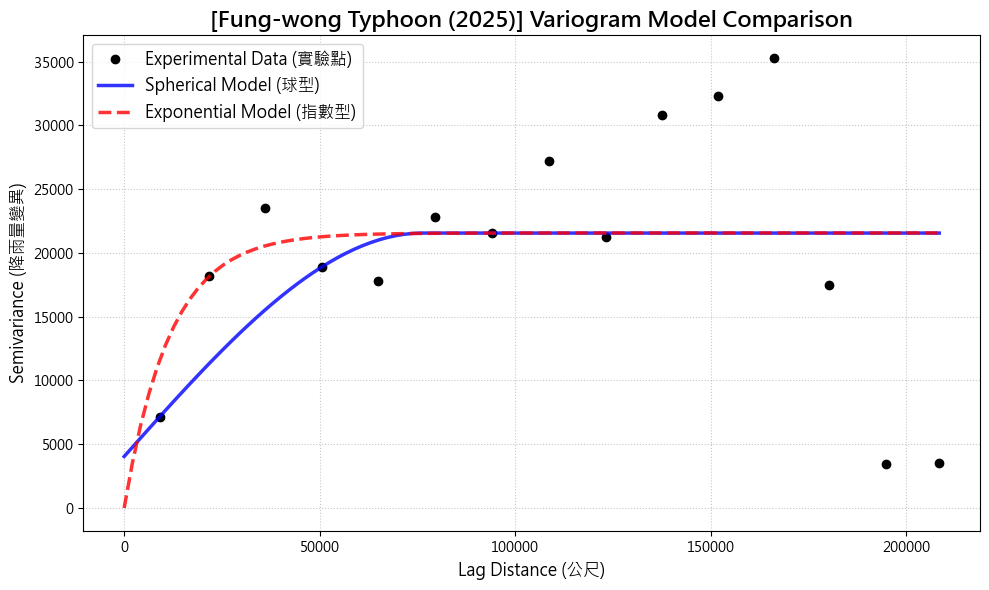

📌 Fung-wong Typhoon (2025) - 參數摘要 (Sill, Range, Nugget):
   [Spherical]   Sill: 17516.58, Range: 76281.17, Nugget: 4039.57
   [Exponential] Sill: 21563.41, Range: 35350.62, Nugget: 0.00
----------------------------------------------------------------------
🚀 開始分析: 0728 Heavy Rain (2025)


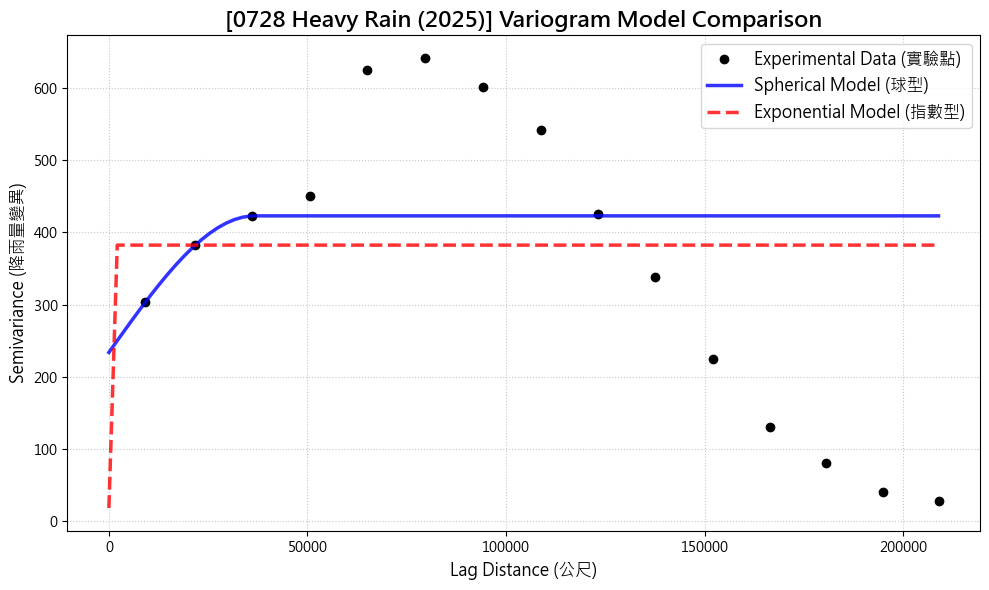

📌 0728 Heavy Rain (2025) - 參數摘要 (Sill, Range, Nugget):
   [Spherical]   Sill: 189.40, Range: 36658.09, Nugget: 233.54
   [Exponential] Sill: 364.57, Range: 132.06, Nugget: 17.80
----------------------------------------------------------------------


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging

# --- 全域設定：解決 matplotlib 中文字體變方塊的問題 ---
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False

def plot_variogram_comparison(gdf, value_col, event_name):
    """
    針對指定事件，計算實驗 Variogram，並擬合 Spherical 與 Exponential 模型。
    產出比較圖並印出關鍵參數。
    """
    print(f"🚀 開始分析: {event_name}")
    
    # 提取坐標與降雨量 (Kriging 吃的是 X=Easting, Y=Northing, Z=Value)
    x = gdf['Easting'].values
    y = gdf['Northing'].values
    z = gdf[value_col].values

    # 建立模型並自動擬合參數 (nlags 設為 15 讓點位分佈較均勻)
    nlags = 15
    ok_sph = OrdinaryKriging(x, y, z, variogram_model='spherical', nlags=nlags)
    ok_exp = OrdinaryKriging(x, y, z, variogram_model='exponential', nlags=nlags)

    # 取得經驗數據 (實驗點)
    lags = ok_sph.lags
    semiv = ok_sph.semivariance

    # 產生平滑的 Lag 距離，用於繪製理論擬合曲線
    smooth_lags = np.linspace(0, max(lags), 100)
    semiv_sph = ok_sph.variogram_function(ok_sph.variogram_model_parameters, smooth_lags)
    semiv_exp = ok_exp.variogram_function(ok_exp.variogram_model_parameters, smooth_lags)

    # ================= 繪製 Variogram 比較圖 =================
    plt.figure(figsize=(10, 6))
    
    # 實驗點
    plt.plot(lags, semiv, 'ko', markersize=6, label='Experimental Data (實驗點)')
    
    # 理論曲線
    plt.plot(smooth_lags, semiv_sph, 'b-', linewidth=2.5, alpha=0.8, label='Spherical Model (球型)')
    plt.plot(smooth_lags, semiv_exp, 'r--', linewidth=2.5, alpha=0.8, label='Exponential Model (指數型)')

    plt.title(f'[{event_name}] Variogram Model Comparison', fontsize=16, fontweight='bold')
    plt.xlabel('Lag Distance (公尺)', fontsize=12)
    plt.ylabel('Semivariance (降雨量變異)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # ================= 印出參數供作業分析使用 =================
    print(f"📌 {event_name} - 參數摘要 (Sill, Range, Nugget):")
    print(f"   [Spherical]   Sill: {ok_sph.variogram_model_parameters[0]:.2f}, Range: {ok_sph.variogram_model_parameters[1]:.2f}, Nugget: {ok_sph.variogram_model_parameters[2]:.2f}")
    print(f"   [Exponential] Sill: {ok_exp.variogram_model_parameters[0]:.2f}, Range: {ok_exp.variogram_model_parameters[1]:.2f}, Nugget: {ok_exp.variogram_model_parameters[2]:.2f}")
    print("-" * 70)
    
    # 回傳這兩個模型，留給下一階段的 Kriging 內插使用
    return ok_sph, ok_exp

# ================= 執行區塊 =================
# 執行分析並將回傳的模型存起來
fungwong_ok_sph, fungwong_ok_exp = plot_variogram_comparison(gdf_fungwong, target_column, 'Fung-wong Typhoon (2025)')
rain0728_ok_sph, rain0728_ok_exp = plot_variogram_comparison(gdf_0728, target_column, '0728 Heavy Rain (2025)')

1. 鳳凰颱風與0728 豪雨事件，兩者最大的差別在Sill。前者Sill極高，顯示出颱風侵襲時，迎風面(特別是蘇澳)降下超高雨量，導致空間落差極大。後者Sill低：這場豪雨的空間降雨在東部地區的落差小，雨勢相對均勻。而Nugget的數值上，鳳凰颱風的 Nugget 為 0，代表雨量展現了極高的空間連續性，這跟颱風性質有很大的關係。而 0728 豪雨有顯著的 Nugget，顯示這波豪雨的降雨空間相關性弱。Range則差不多，都受到中央山脈地形影響。

2. 根據分析，鳳凰颱風模型選擇為Exponential (指數型)。紅色的虛線在短距離（X軸 0 ~ 50,000 公尺）緊緊貼著黑點上升，且 Nugget 為 0。這代表鳳凰颱風在 50 公里內的降雨是高度連續漸變的。而0728 豪雨事件因為降雨空間相關性太弱，導致 Exponential 模型的演算法在短距離內找不到平滑的上升曲線，因此會考慮Spherical 模型。

🛰️ 啟動雷達掃描，正在繪製測站降雨分佈...


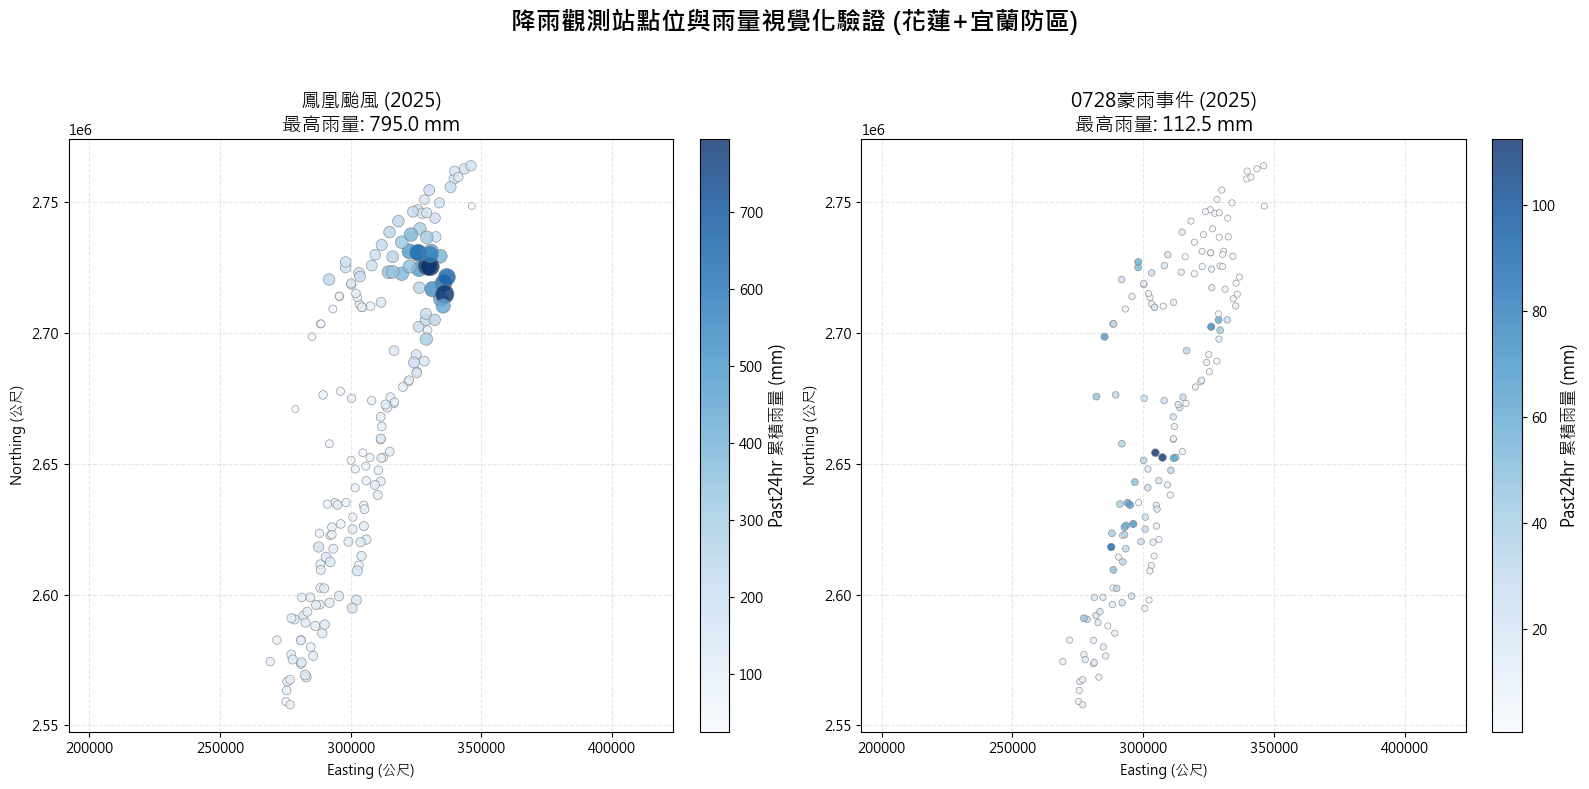

In [19]:
import matplotlib.pyplot as plt

# 確保中文字體顯示正常
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False

def plot_station_bubble_map(gdf_1, name_1, gdf_2, name_2, value_col='Past24hr'):
    """
    繪製兩個 GeoDataFrame 的點位雨量分佈圖，
    以點的大小和顏色深淺來表示雨量多寡。
    """
    print("🛰️ 啟動雷達掃描，正在繪製測站降雨分佈...")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle('降雨觀測站點位與雨量視覺化驗證 (花蓮+宜蘭防區)', fontsize=18, fontweight='bold')
    
    # 設定圖表參數
    gdfs = [(gdf_1, name_1), (gdf_2, name_2)]
    
    for i, (gdf, name) in enumerate(gdfs):
        ax = axes[i]
        
        # 為了讓雨量差異更明顯，點的大小 (markersize) 設定為：基礎大小 + (雨量值 * 權重)
        # 針對極端降雨可調整除數，避免點位過大遮蔽
        weight = 5 if gdf[value_col].max() > 500 else 10
        base_size = 20
        marker_sizes = base_size + (gdf[value_col] / weight) 
        
        # 繪製點位
        scatter = ax.scatter(
            gdf['Easting'], gdf['Northing'], 
            s=marker_sizes, 
            c=gdf[value_col], 
            cmap='Blues', 
            alpha=0.8, 
            edgecolors='grey', 
            linewidths=0.5
        )
        
        # 設定標題與外觀
        ax.set_title(f'{name}\n最高雨量: {gdf[value_col].max():.1f} mm', fontsize=14)
        ax.set_xlabel('Easting (公尺)')
        ax.set_ylabel('Northing (公尺)')
        
        # 加上 Colorbar
        cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(f'{value_col} 累積雨量 (mm)', fontsize=12)
        
        # 保持坐標軸等比例，讓台灣地形不變形
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.axis('equal') 

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# ================= 執行區塊 =================
# 將剛剛處理好的鳳凰與0728資料丟進去畫圖
plot_station_bubble_map(gdf_fungwong, '鳳凰颱風 (2025)', gdf_0728, '0728豪雨事件 (2025)', value_col=target_column)

📝 **Captain's Log: Phase 3 - A2. 四種方法內插 與 A3. 不確定性分析**

在 1000m 解析度網格上，比較四種不同的空間內插演算法（Nearest Neighbor, IDW, Ordinary Kriging, Random Forest），並輸出 2x2 視覺化比較圖與 Kriging vs RF 的差異圖。

🚀 啟動 Typhoon Fung-wong (2025) 內插運算核心...
   [1/4] Nearest Neighbor...
   [2/4] IDW...
   [3/4] Ordinary Kriging...
   [4/4] Random Forest...


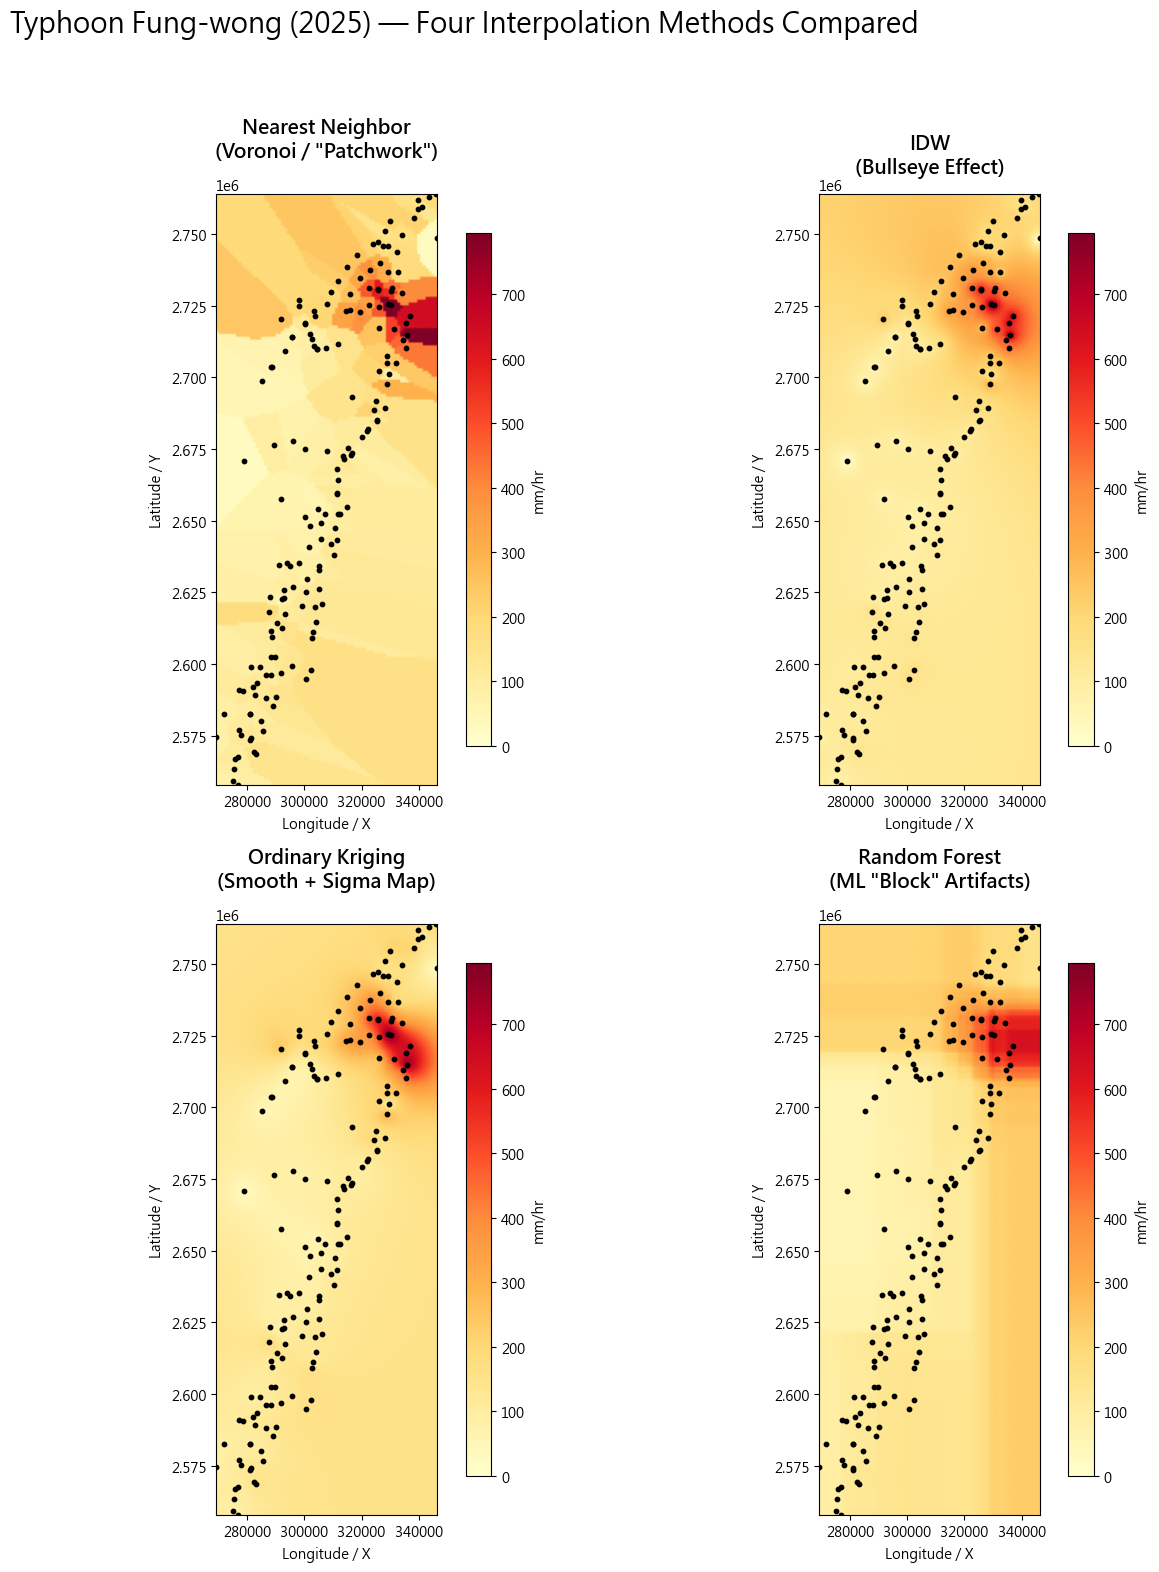

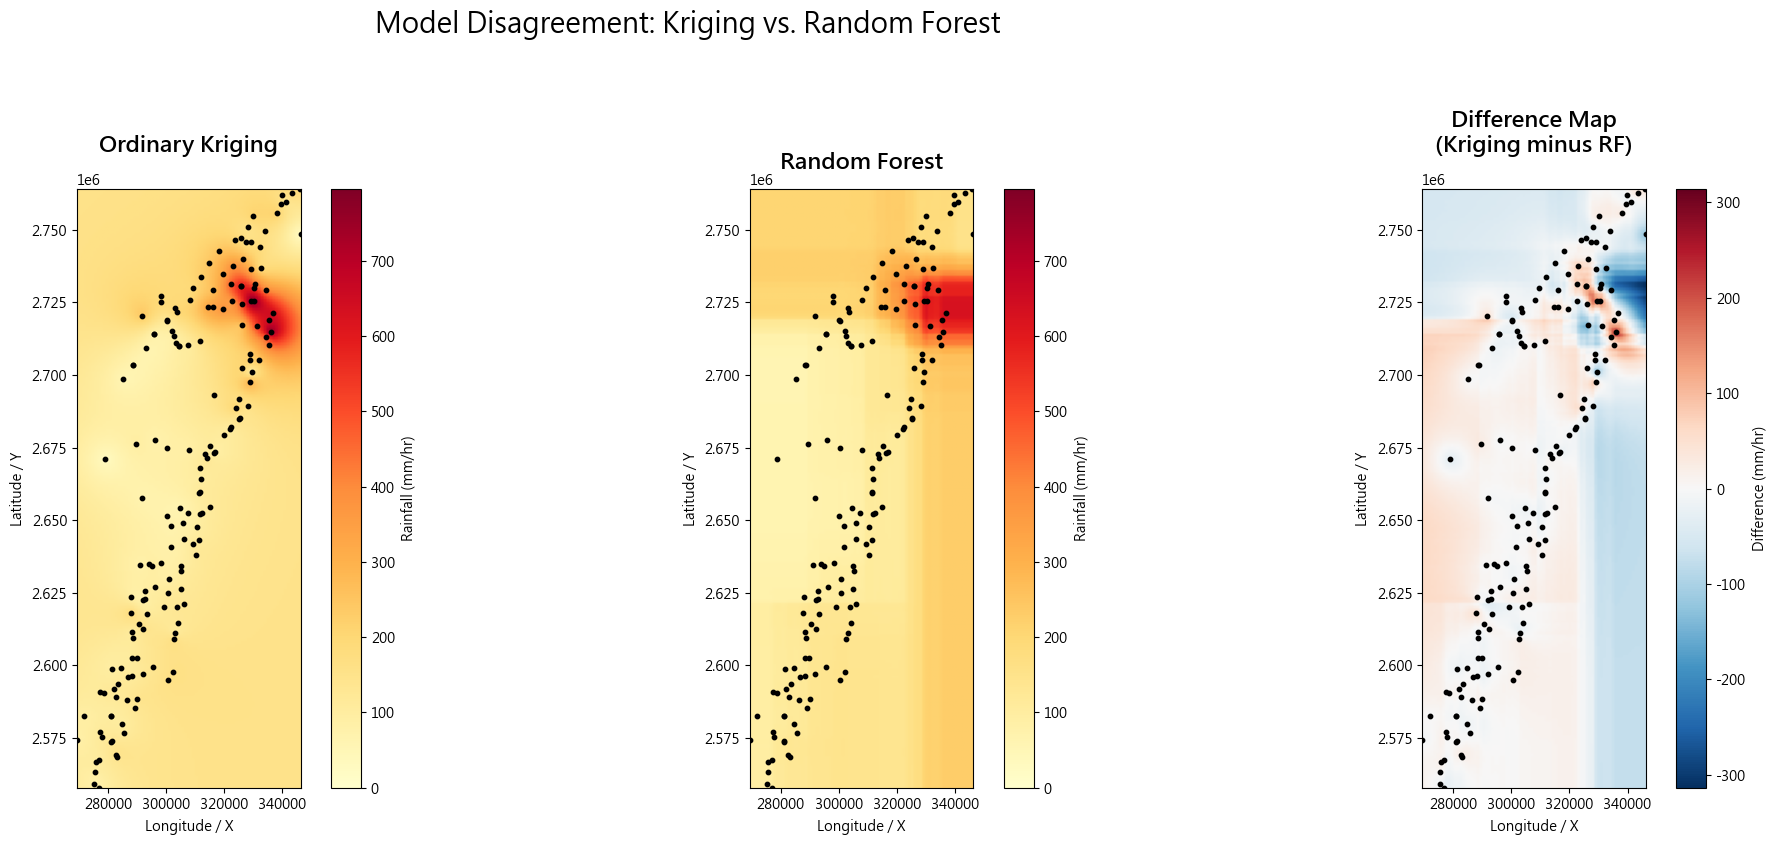

🚀 啟動 0728 Heavy Rain (2025) 內插運算核心...
   [1/4] Nearest Neighbor...
   [2/4] IDW...
   [3/4] Ordinary Kriging...
   [4/4] Random Forest...


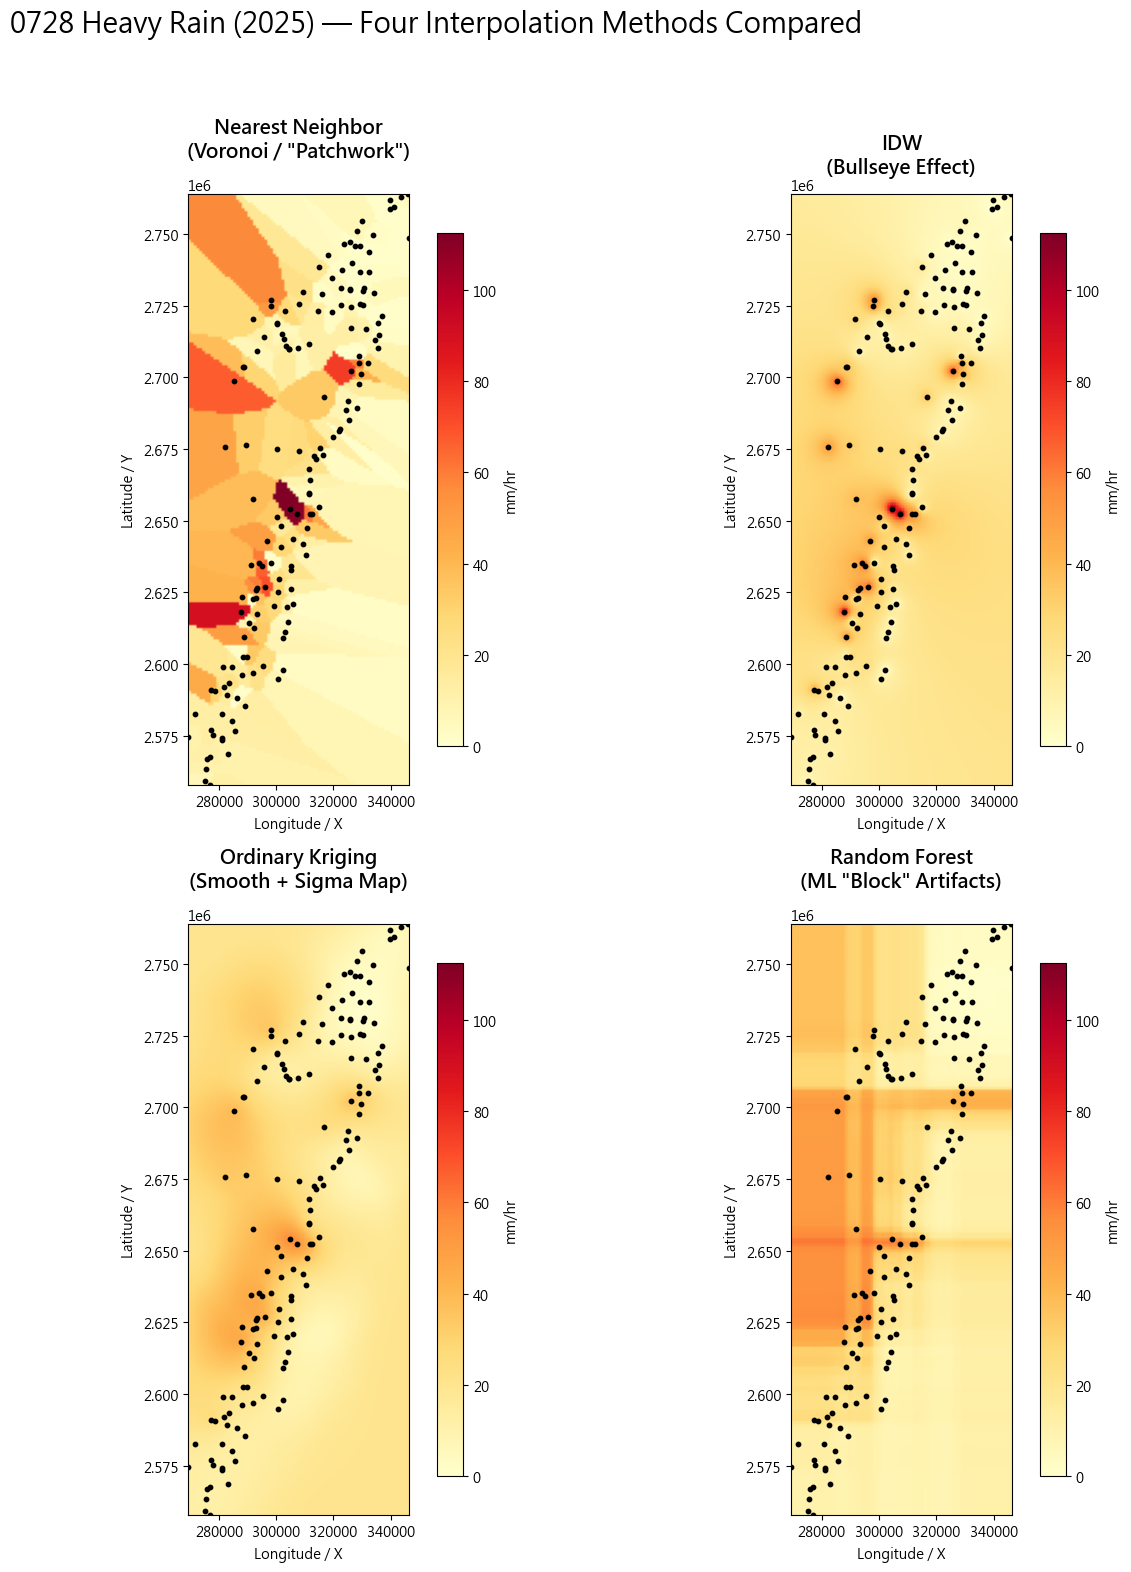

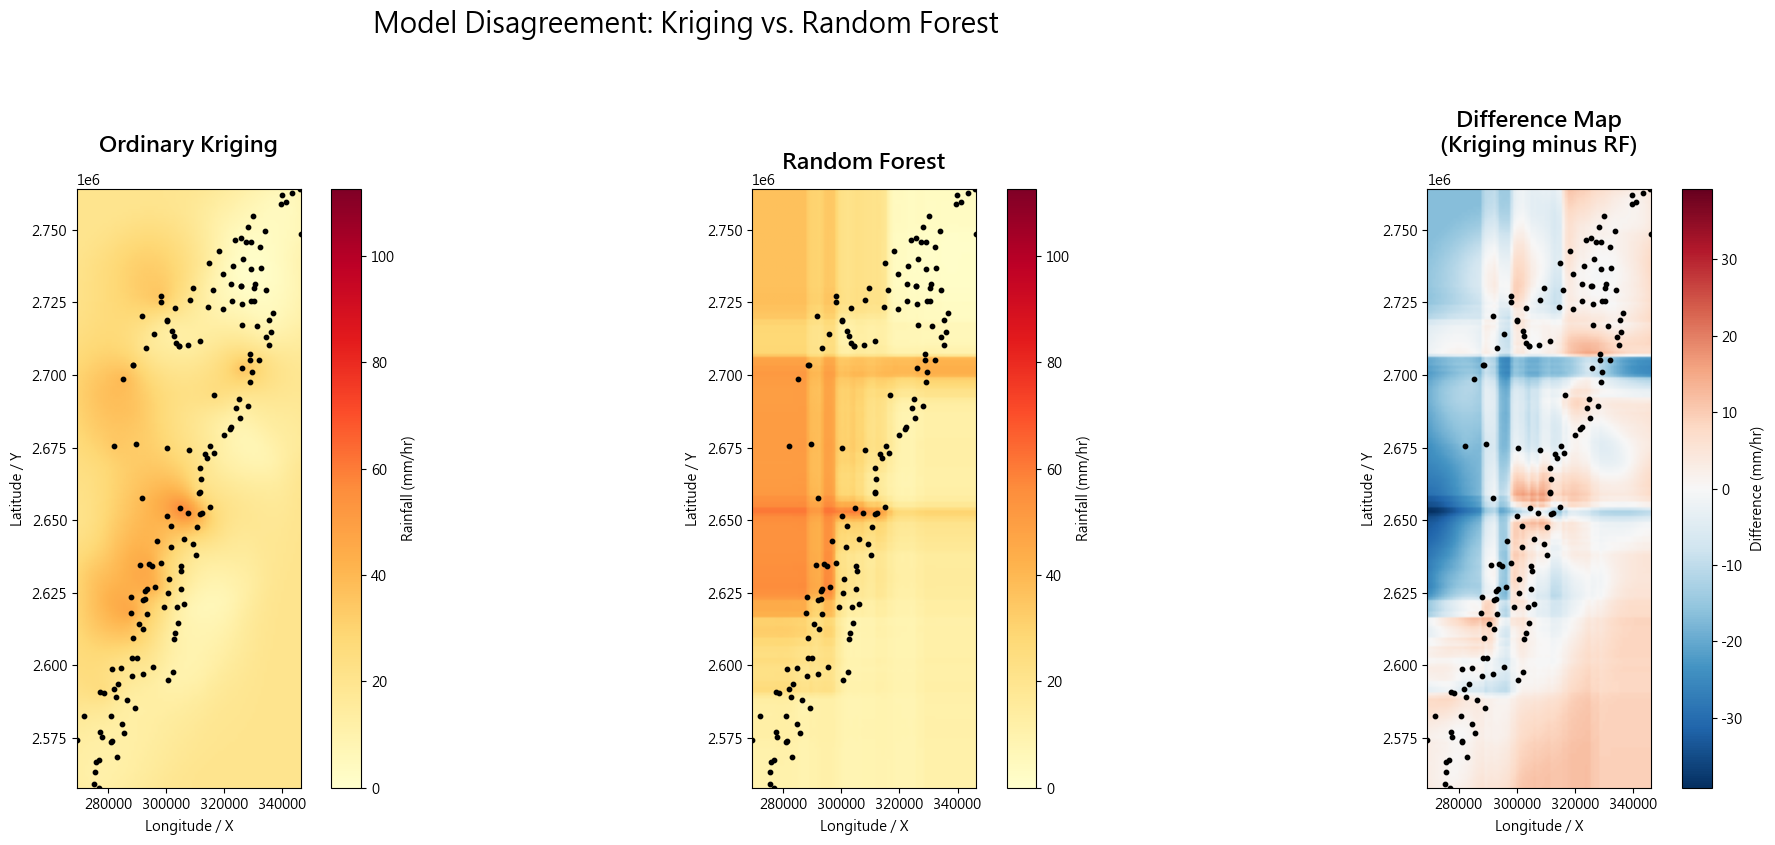

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist
from sklearn.ensemble import RandomForestRegressor

# 確保輸出資料夾存在
os.makedirs('output', exist_ok=True)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

def run_ultimate_shootout(gdf, value_col, ok_model, event_name, event_prefix):
    print(f"🚀 啟動 {event_name} 內插運算核心...")
    
    # 1. 建立 1000m 解析度網格
    minx, miny, maxx, maxy = gdf.total_bounds
    grid_x = np.arange(minx, maxx, 1000)
    grid_y = np.arange(miny, maxy, 1000)
    xx, yy = np.meshgrid(grid_x, grid_y)
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    obs_x = gdf['Easting'].values
    obs_y = gdf['Northing'].values
    obs_z = gdf[value_col].values
    
    # --- 模型計算 ---
    print("   [1/4] Nearest Neighbor...")
    nn_interp = NearestNDInterpolator(list(zip(obs_x, obs_y)), obs_z)
    z_nn = nn_interp(xx, yy)
    
    print("   [2/4] IDW...")
    dist = cdist(grid_points, np.column_stack((obs_x, obs_y)))
    dist[dist == 0] = 1e-10 
    weights = 1.0 / (dist ** 2)
    z_idw = (np.sum(weights * obs_z, axis=1) / np.sum(weights, axis=1)).reshape(xx.shape)
    
    print("   [3/4] Ordinary Kriging...")
    z_krige_raw, ss_krige_raw = ok_model.execute('grid', grid_x, grid_y)
    z_krige = z_krige_raw.data
    sigma_map = np.sqrt(ss_krige_raw.data) # 不確定性 (標準差)
    
    print("   [4/4] Random Forest...")
    rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)
    rf.fit(np.column_stack((obs_x, obs_y)), obs_z)
    z_rf = rf.predict(grid_points).reshape(xx.shape)
    
    extent = [minx, maxx, miny, maxy]
    rain_cmap = 'YlOrRd'
    vmax_rain = np.max(obs_z)
    
    # ================= 圖表 1：四種方法比較 (2x2) =================
    fig1, axes1 = plt.subplots(2, 2, figsize=(14, 16))
    fig1.suptitle(f'{event_name} — Four Interpolation Methods Compared', fontsize=20, y=0.98)
    
    methods = [
        ('Nearest Neighbor\n(Voronoi / "Patchwork")', z_nn), 
        ('IDW\n(Bullseye Effect)', z_idw),
        ('Ordinary Kriging\n(Smooth + Sigma Map)', z_krige), 
        ('Random Forest\n(ML "Block" Artifacts)', z_rf)
    ]
    
    for ax, (title, z_data) in zip(axes1.flatten(), methods):
        im = ax.imshow(z_data, origin='lower', extent=extent, cmap=rain_cmap, vmin=0, vmax=vmax_rain)
        ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
        ax.scatter(obs_x, obs_y, c='black', s=10)
        ax.set_xlabel('Longitude / X')
        ax.set_ylabel('Latitude / Y')
        plt.colorbar(im, ax=ax, fraction=0.036, pad=0.04, label='mm/hr')
        
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f"output/{event_prefix}_1_四種內插比較圖.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    # ================= 圖表 2：Kriging vs RF 差異圖 (1x3) =================
    fig2, axes2 = plt.subplots(1, 3, figsize=(22, 8))
    fig2.suptitle('Model Disagreement: Kriging vs. Random Forest', fontsize=20, y=1.05)
    
    # OK 圖
    im0 = axes2[0].imshow(z_krige, origin='lower', extent=extent, cmap=rain_cmap, vmin=0, vmax=vmax_rain)
    axes2[0].scatter(obs_x, obs_y, c='black', s=10)
    axes2[0].set_title('Ordinary Kriging', fontsize=16, fontweight='bold', pad=15)
    plt.colorbar(im0, ax=axes2[0], fraction=0.046, pad=0.04, label='Rainfall (mm/hr)')
    
    # RF 圖
    im1 = axes2[1].imshow(z_rf, origin='lower', extent=extent, cmap=rain_cmap, vmin=0, vmax=vmax_rain)
    axes2[1].scatter(obs_x, obs_y, c='black', s=10)
    axes2[1].set_title('Random Forest', fontsize=16, fontweight='bold', pad=15)
    plt.colorbar(im1, ax=axes2[1], fraction=0.046, pad=0.04, label='Rainfall (mm/hr)')
    
    # 差異圖
    z_diff = z_krige - z_rf
    max_diff = max(abs(np.nanmin(z_diff)), abs(np.nanmax(z_diff)))
    im2 = axes2[2].imshow(z_diff, origin='lower', extent=extent, cmap='RdBu_r', vmin=-max_diff, vmax=max_diff)
    axes2[2].scatter(obs_x, obs_y, c='black', s=10)
    axes2[2].set_title('Difference Map\n(Kriging minus RF)', fontsize=16, fontweight='bold', pad=15)
    plt.colorbar(im2, ax=axes2[2], fraction=0.046, pad=0.04, label='Difference (mm/hr)')
    
    for ax in axes2:
        ax.set_xlabel('Longitude / X')
        ax.set_ylabel('Latitude / Y')
        
    plt.tight_layout()
    plt.savefig(f"output/{event_prefix}_2_差異圖.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


# ================= 執行區塊 =================
# 🚨 記得使用前一步驟挑出的「最佳模型」
# 鳳凰颱風 (高變異，最佳為 Exponential)
run_ultimate_shootout(gdf_fungwong, target_column, fungwong_ok_exp, 'Typhoon Fung-wong (2025)', '鳳凰颱風')

# 0728 豪雨 (低變異，最佳為 Spherical)
run_ultimate_shootout(gdf_0728, target_column, rain0728_ok_sph, '0728 Heavy Rain (2025)', '0728豪雨')

📊 正在為 Typhoon Fung-wong (2025) 生成不確定性分析圖 (Sigma Map)...


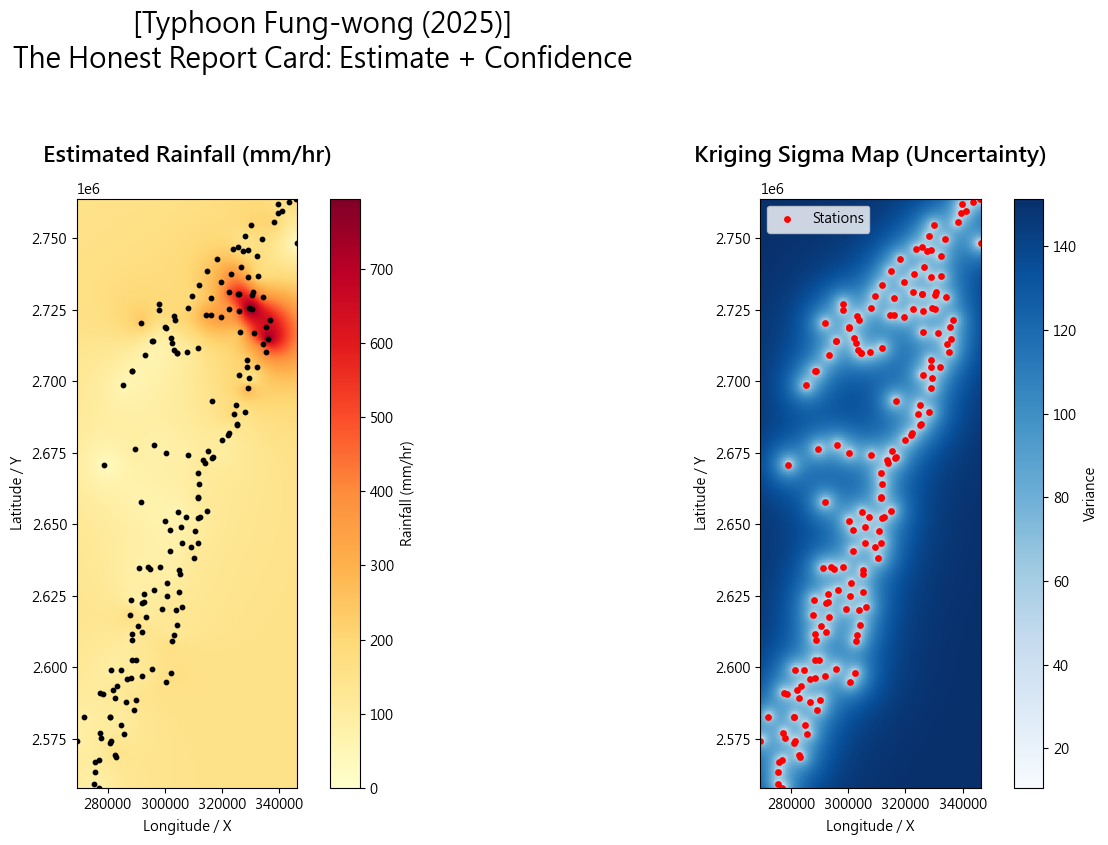

✅ 已成功匯出: output/鳳凰颱風_3_SigmaMap.png
--------------------------------------------------
📊 正在為 0728 Heavy Rain (2025) 生成不確定性分析圖 (Sigma Map)...


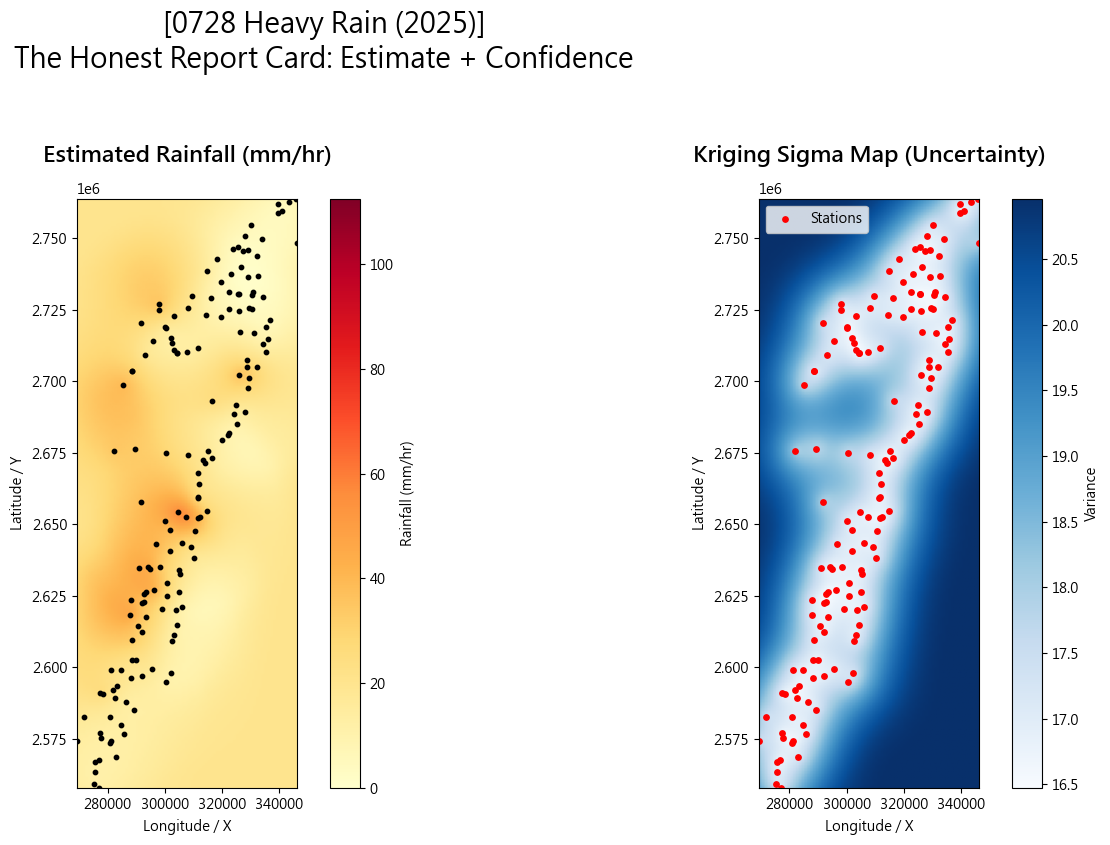

✅ 已成功匯出: output/0728豪雨_3_SigmaMap.png
--------------------------------------------------


In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 確保輸出資料夾存在
os.makedirs('output', exist_ok=True)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

def generate_honest_report_card(gdf, value_col, ok_model, event_name, event_prefix):
    """
    單獨執行 Kriging 內插，並產出預測圖與 Sigma Map 不確定性分析圖。
    """
    print(f"📊 正在為 {event_name} 生成不確定性分析圖 (Sigma Map)...")

    # 1. 準備觀測資料與空間邊界 (補齊 extent, obs_x, obs_y)
    minx, miny, maxx, maxy = gdf.total_bounds
    extent = [minx, maxx, miny, maxy]
    
    obs_x = gdf['Easting'].values
    obs_y = gdf['Northing'].values
    obs_z = gdf[value_col].values
    
    # 2. 建立 1000m 解析度網格
    grid_x = np.arange(minx, maxx, 1000)
    grid_y = np.arange(miny, maxy, 1000)

    # 3. 執行 Kriging 計算 (補齊 z_krige 與 sigma_map)
    # ok_model.execute 會回傳預測值與變異數 (Variance)
    z_krige_raw, ss_krige_raw = ok_model.execute('grid', grid_x, grid_y)
    z_krige = z_krige_raw.data
    sigma_map = np.sqrt(ss_krige_raw.data) # 取標準差作為不確定性指標

    # 4. 設定視覺化參數 (補齊 colormap 與最大值)
    rain_cmap = 'YlOrRd'
    vmax_rain = np.max(obs_z)

    # ================= 圖表 3：不確定性分析 Sigma Map (1x2) =================
    # (這裡完美銜接您拆出來的 code)
    fig3, axes3 = plt.subplots(1, 2, figsize=(16, 8))
    
    # 微調標題，把事件名稱加進去會更清楚
    fig3.suptitle(f'[{event_name}]\nThe Honest Report Card: Estimate + Confidence', fontsize=20, y=1.05)
    
    # 預測圖
    im_est = axes3[0].imshow(z_krige, origin='lower', extent=extent, cmap=rain_cmap, vmin=0, vmax=vmax_rain)
    axes3[0].scatter(obs_x, obs_y, c='black', s=10)
    axes3[0].set_title('Estimated Rainfall (mm/hr)', fontsize=16, fontweight='bold', pad=15)
    plt.colorbar(im_est, ax=axes3[0], fraction=0.046, pad=0.04, label='Rainfall (mm/hr)')
    
    # 信心圖 (Sigma Map)
    im_sig = axes3[1].imshow(sigma_map, origin='lower', extent=extent, cmap='Blues')
    axes3[1].scatter(obs_x, obs_y, c='red', s=15, label='Stations')
    axes3[1].set_title('Kriging Sigma Map (Uncertainty)', fontsize=16, fontweight='bold', pad=15)
    axes3[1].legend()
    plt.colorbar(im_sig, ax=axes3[1], fraction=0.046, pad=0.04, label='Variance')
    
    for ax in axes3:
        ax.set_xlabel('Longitude / X')
        ax.set_ylabel('Latitude / Y')
        
    plt.tight_layout()
    plt.savefig(f"output/{event_prefix}_3_SigmaMap.png", dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✅ 已成功匯出: output/{event_prefix}_3_SigmaMap.png")
    print("-" * 50)

# ================= 執行區塊 =================
# 執行鳳凰颱風 (使用前面算出的最佳 Exponential 模型)
generate_honest_report_card(gdf_fungwong, target_column, fungwong_ok_exp, 'Typhoon Fung-wong (2025)', '鳳凰颱風')

# 執行0728豪雨 (使用前面算出的最佳 Spherical 模型)
generate_honest_report_card(gdf_0728, target_column, rain0728_ok_sph, '0728 Heavy Rain (2025)', '0728豪雨')

A3. 不確定性比較分析
1. Sigma Map 的差異與原因

鳳凰颱風的 Sigma Map 呈現出極高的整體變異值，且在無測站區域誤差會急遽飆升；0728 豪雨的 Sigma 變異值則相對低且平緩。這是因為鳳凰颱風降雨型態導致高Sill的特質，而 0728 豪雨降雨分佈較為均勻，Sill低，內插的穩定度自然較高。

2. Kriging 的預測信心

對於「0728 豪雨」這類降雨平穩、空間變異小的事件，Kriging 的預測信心較高。面對颱風極端降雨，Kriging 在測站稀疏區的推估信心會大幅下降。


3. 指揮官決策

在高 variance（高不確定性）區域，代表空間內插的情報不太可靠。如果是我不會只用這些預測盲區的數據下達撤離決策，會使用其他輔助資料，或是輔以衛星雲圖進行交叉驗證。

4. Random Forest 與不確定性資訊

傳統 Random Forest 無法提供類似的機率性誤差資訊。從圖形中 RF 明顯的方塊狀邊界可以知道此方法是依賴決策樹進行空間特徵切割，只能給出一個絕對的平均預測值，無法嚴謹解算出該點的數學變異量。


📝 **Captain's Log: Phase 4 - 產出 GeoTIFF Export**

將鳳凰颱風的 Kriging 結果匯出成 GeoTIFF 格式。

In [27]:
import rasterio
from rasterio.transform import from_origin
import numpy as np
from sklearn.ensemble import RandomForestRegressor

def export_rainfall_geotiff(gdf, value_col, ok_model, export_prefix="fungwong"):
    """
    重新擷取網格資料，並將內插結果導出為 GeoTIFF 檔案 (EPSG:3826)。
    """
    print("📦 準備導出 GeoTIFF，正在重新擷取網格與預測數據...")
    
    # 1. 建立 1000m 解析度網格
    minx, miny, maxx, maxy = gdf.total_bounds
    grid_x = np.arange(minx, maxx, 1000)
    grid_y = np.arange(miny, maxy, 1000)
    xx, yy = np.meshgrid(grid_x, grid_y)
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    obs_x = gdf['Easting'].values
    obs_y = gdf['Northing'].values
    obs_z = gdf[value_col].values
    
    # 2. 快速重算 Kriging 與 Random Forest 矩陣
    print("⏳ 正在計算 Kriging 與 Random Forest...")
    z_krige_raw, ss_krige_raw = ok_model.execute('grid', grid_x, grid_y)
    z_krige = z_krige_raw.data
    ss_krige = ss_krige_raw.data # Variance
    
    rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)
    rf.fit(np.column_stack((obs_x, obs_y)), obs_z)
    z_rf = rf.predict(grid_points).reshape(xx.shape)
    
    # 3. 定義空間參數與導出
    res = 1000 
    transform = from_origin(grid_x.min(), grid_y.max(), res, res)
    
    def save_tif(data, filename):
        # 🚨 指揮官提醒：numpy 陣列的 row 0 通常對應南邊，
        # 但 GeoTIFF 規範 row 0 必須從北端開始，因此必須執行 flipud 翻轉！
        output_data = np.flipud(data).astype('float32')
        
        with rasterio.open(
            filename, 'w',
            driver='GTiff',
            height=output_data.shape[0],
            width=output_data.shape[1],
            count=1,
            dtype=output_data.dtype,
            crs='EPSG:3826',
            transform=transform,
        ) as dst:
            dst.write(output_data, 1)
        print(f"✅ 成功產出檔案: {filename}")

    # 開始寫入
    print("💾 開始寫入 GeoTIFF 檔案...")
    # 依照作業需求命名
    save_tif(z_krige, f"{export_prefix}_kriging_rainfall.tif")
    save_tif(ss_krige, f"{export_prefix}_kriging_variance.tif")
    save_tif(z_rf, f"{export_prefix}_rf_rainfall.tif")

# ================= 執行區塊 =================
# 針對鳳凰颱風的運算結果執行導出
# 記得傳入正確的 gdf, 數值欄位, 以及最佳模型 (fungwong_ok_exp)
export_rainfall_geotiff(gdf_fungwong, target_column, fungwong_ok_exp, export_prefix="fungwong")

📦 準備導出 GeoTIFF，正在重新擷取網格與預測數據...
⏳ 正在計算 Kriging 與 Random Forest...
💾 開始寫入 GeoTIFF 檔案...
✅ 成功產出檔案: fungwong_kriging_rainfall.tif
✅ 成功產出檔案: fungwong_kriging_variance.tif
✅ 成功產出檔案: fungwong_rf_rainfall.tif


## A5. 跨事件綜合比較

**1. 兩事件 Variogram 參數比較表**

| 參數 |鳳凰颱風 | 0728 豪雨 | 差異原因分析 (大氣與地理機制) |
|------|------------------------|-------------------------|--------------------------------------------------|
| **Sill**  | ~21563 (極大) | ~423 (極小) |鳳凰颱風挾帶極端強降雨且迎風面影響大，；0728 豪雨為東部整體雨勢較為均勻，空間梯度小。 |
| **Range**  | ~35.3 公里 | 約 30~40 公里 |兩者皆落在 30-40 公里左右，反映了宜花有中央山脈阻擋的地理限制，降雨特徵通常在跨越一定距離後就會改變。 |
| **Nugget**  | 0.00 | ~235 (顯著) | 鳳凰颱風降雨連續性極高，；0728 豪雨東部降雨量較小且無明顯空間連續性，有出現無法被模型解釋的隨機降雨跳動。 |
| **Best Model** | Exponential (指數型) | Spherical (球型) | 鳳凰颱風的案例，指數型能貼合颱風短距離內連續且無截距 (Nugget=0) 的劇烈變化。0728 豪雨案例對於東部影響小且降雨較均勻，短距離的狀況較平緩，因此選擇Spherical。 |

<br>

**2.如果只能用一組參數套用到未來所有事件，會怎麼選？為什麼這樣做有風險？**

我會選擇以歷史極端颱風事件的參數為基準，並加上適度的 Nugget 進行容錯。雖然這樣會不準確，但寧可高估空間的變異與風險。這種只用一組參數的做法在空間統計具有風險，例如天氣雨量狀態會影響Sill，如果用 0728 豪雨的平緩參數去預測鳳凰颱風，模型會過度平滑化，導致嚴重低估山區的極端致災降雨。 